<h1><center> <ins><b> Option Value Calculator</b></ins></center></h1>

In this notebook we will provide some code to find the value of European and Binary Call/Put Options given enough information. The information required are the:
- Underlying asset price (S)
- Strike Price (K)
- Interest rate (r)
- Continuous Dividend Yield (q)
- Volatility ($\sigma$)
- Time from beginning until expiry (T)
- Current time (t)

We will be using the formulae we have derived in the **Black-Scholes Equation and Option Values Derivation** notebook. I have copied it down below for reference and clarity.
<br><br>
$$\Large \boxed{V_{EC_{D}}(S,t)=Se^{-q\,\left(T-t\right)} N(d_1) - Ke^{-r\,\left(T-t\right)} N(d_2)}$$\
$$\Large \boxed{V_{EP_{D}}(S,t)= -Se^{-q\,\left(T-t\right)} N(-d_1) + Ke^{-r\left(T-t\right)} N(-d_2)}$$\
$$\Large \boxed{V_{BC}(S,t)= e^{-r\left(T-t\right)} N(d_2)}$$\
$$\Large \boxed{V_{BP}(S,t)= e^{-r\left(T-t\right)} N(-d_2)}$$\
where
$$\Large d_1 = \frac{\left(\log{S/K}+\left(r-q+\frac{1}{2}\sigma^{2}\right)\left(T-t\right) \right) }{\sigma\,\sqrt{T-t}}$$
and 
$$\Large d_2 = \frac{\left(\log{S/K}+\left(r-q-\frac{1}{2}\sigma^{2}\right)\left(T-t\right) \right) }{\sigma\,\sqrt{T-t}}=d_1 - \sigma\sqrt{T-t}$$\
We will write a file full of these 4 options and corresponding random values for the parameters for variables, making sure they are sensible, and then we will read that file and make a dataframe from it. We will then add a new column for the values of the options that have been worked out from the Black-Scholes formulae. Finally, we will write a new file from this.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define d1, d2, n(x)
def d1(S,K,r,q,sigma,T,t):
    d1=(np.log(S/K)+((r-q+((sigma**2)/2))*(T-t)))/(sigma*np.sqrt((T-t)))
    return d1
def d2(S,K,r,q,sigma,T,t):
    d2=(np.log(S/K)+(r-q-((sigma**2)/2))*(T-t))/(sigma*np.sqrt((T-t)))    
    return d2
def n(x):
    ans=np.exp(-(x**2)/2)/(np.sqrt(2*np.pi))   
    return ans

In [3]:
# Define Option Values for the 4 types of options
def Value_EC(S,K,r,q,sigma,T,t):
    OVEC= (S*(stats.norm.cdf(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t))))-(K*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))
    return OVEC
def Value_EP(S,K,r,q,sigma,T,t):
    OVEP= -(S*(stats.norm.cdf(-(d1(S,K,r,q,sigma,T,t))))*(np.exp(-q*(T-t))))+(K*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))
    return OVEP
def Value_BC(S,K,r,q,sigma,T,t):
    OVBC= (stats.norm.cdf(d1(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t)))
    return OVBC
def Value_BP(S,K,r,q,sigma,T,t):
    OVBP= (stats.norm.cdf(-(d1(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t)))
    return OVBP

In [4]:
# Writing a file full of options and required information

# Choose how many options we want
n=1000

options = []
temp = ['EC', 'EP', 'BC', 'BP']
S,K,r,q,sigma,T,t = [np.zeros(n) for _ in range(7)]

# For reproducibility of results
random.seed(0)

for i in range(n):
    options.append(random.choices(temp, weights=[10,10,1,1], k=1)[0])
    S[i] = random.randint(50,150)
    K[i] = random.randint(S[i]-20,S[i]+20)
    r[i] = round(random.uniform(0.01,0.1), 3)
    q[i] = round(random.uniform(0,0.2), 3)
    sigma[i] = round(random.uniform(0.1,0.4), 3)
    T[i] = random.randint(1,5)
    t[i] = round(T[i] - random.uniform(0,T[i]), 2)
    if T[i] == t[i]:
        t[i] = t[i]-0.01  #Ensures that T =/= t, else we will have problems with dividing by 0
# Writing to a directory
df = pd.DataFrame(data={"option_type": options, "S": S, "K": K, "r": r, "q": q, "sigma": sigma, "T": T, "t": t})
df.to_csv("/Users/Sajeeth/Documents/Quant Portfolio/Option Pricing Models/Black Scholes Deep Dive/Value_Calculator_Test_Data2.csv", sep=',',index=False)

In [5]:
# Reading the file as a dataframe and finding the values of each option and inserting it into the dataframe
# Alternatively, make a preset file of options and required info and then read this. For example,
# df = pd.read_csv('/Users/Sajeeth/Documents/Quant Portfolio/Option Pricing Models/Black Scholes Deep Dive/Value_Calculator_Test_Data.csv')
df = pd.read_csv('/Users/Sajeeth/Documents/Quant Portfolio/Option Pricing Models/Black Scholes Deep Dive/Value_Calculator_Test_Data2.csv')
df['value']=None

for i in range(len(df)):
    if 'EC' in df['option_type'][i]:
        df.loc[i,('value')] = Value_EC(df.loc[i,('S')],df.loc[i,('K')],df.loc[i,('r')],df.loc[i,('q')],df.loc[i,('sigma')],df.loc[i,('T')],df.loc[i,('t')])
    elif 'EP' in df['option_type'][i]:
        df.loc[i,('value')] = Value_EP(df.loc[i,('S')],df.loc[i,('K')],df.loc[i,('r')],df.loc[i,('q')],df.loc[i,('sigma')],df.loc[i,('T')],df.loc[i,('t')])
    elif 'BC' in df['option_type'][i]:
        df.loc[i,('value')] = Value_BC(df.loc[i,('S')],df.loc[i,('K')],df.loc[i,('r')],df.loc[i,('q')],df.loc[i,('sigma')],df.loc[i,('T')],df.loc[i,('t')])
    elif 'BP' in df['option_type'][i]:
        df.loc[i,('value')] = Value_BP(df.loc[i,('S')],df.loc[i,('K')],df.loc[i,('r')],df.loc[i,('q')],df.loc[i,('sigma')],df.loc[i,('T')],df.loc[i,('t')])
    else:
        df.loc[i,('value')] = np.nan

# Check to see if dataframe looks okay
df

,option_type,S,K,r,q,sigma,T,t,value
0,EP,147.0,153.0,0.014,0.193,0.246,3.0,0.10,64.857244
1,EC,77.0,89.0,0.023,0.028,0.128,3.0,0.04,2.307261
2,EP,140.0,158.0,0.091,0.062,0.319,3.0,1.58,25.886804
3,EC,105.0,105.0,0.065,0.183,0.390,4.0,2.23,9.881671
4,EP,57.0,72.0,0.092,0.019,0.352,1.0,0.39,14.197704
...,...,...,...,...,...,...,...,...,...
995,EP,120.0,135.0,0.055,0.012,0.233,2.0,0.06,17.511332
996,EP,71.0,79.0,0.090,0.178,0.129,3.0,0.96,16.639523
997,EC,123.0,131.0,0.078,0.048,0.120,4.0,2.07,7.183228
998,EP,86.0,84.0,0.088,0.121,0.102,2.0,1.54,1.913252


In [6]:
# Creating a new .csv file that includes the value of each corresponding option

df.to_csv('/Users/Sajeeth/Documents/Quant Portfolio/Option Pricing Models/Black Scholes Deep Dive/Value_Calculator_Results.csv', encoding='utf-8', index=False, header=True)

If we are given the parameters for a singular option, we can also see how volatility and strike price affect our final option value by visually plotting a heatmap.

In [7]:
def Heatmap(S,K,r,q,sigma,T,t):
    strike_range = np.linspace(K-20, K+20, 11) if K>=20 else np.linspace(0, 2*K, 11)
    sigma_range = np.linspace(sigma+0.1, sigma-0.1, 11) if sigma>=0.1 else np.linspace(2*sigma, 0, 11)
    Ecall_values = np.zeros((len(sigma_range),len(strike_range)))
    Eput_values = np.zeros((len(sigma_range),len(strike_range)))
    Bcall_values = np.zeros((len(sigma_range),len(strike_range)))
    Bput_values = np.zeros((len(sigma_range),len(strike_range)))
     
    for i,sigma1 in enumerate(sigma_range):
        for j,strike1 in enumerate(strike_range):
            Ecall_values[i,j] = Value_EC(S,strike1,r,q,sigma1,T,t)
            Eput_values[i,j] = Value_EP(S,strike1,r,q,sigma1,T,t)
            Bcall_values[i,j] = Value_BC(S,strike1,r,q,sigma1,T,t)
            Bput_values[i,j] = Value_BP(S,strike1,r,q,sigma1,T,t)
    
    # Initialising plots
    fig, ([ax_Ecall,ax_Eput],[ax_Bcall,ax_Bput]) = plt.subplots(nrows=2, ncols=2, figsize=(35, 30))
    # Plotting European Call Price Heatmap
    
    sns.heatmap(Ecall_values, xticklabels=np.round(strike_range, 2), yticklabels=np.round(sigma_range, 2), annot=True, annot_kws={"fontsize":20}, fmt=".2f", cmap="inferno", ax=ax_Ecall)
    ax_Ecall.tick_params(axis='both', which='major', labelsize=20)
    ax_Ecall.figure.axes[-1].tick_params(labelsize=20)
    ax_Ecall.set_title('EUROPEAN CALL', fontsize=60)
    ax_Ecall.set_xlabel('Strike Price', fontsize=40)
    ax_Ecall.set_ylabel('Volatility', fontsize=40)
    
    # Plotting European Put Price Heatmap
    sns.heatmap(Eput_values, xticklabels=np.round(strike_range, 2), yticklabels=np.round(sigma_range, 2), annot=True, annot_kws={"fontsize":20}, fmt=".2f", cmap="inferno", ax=ax_Eput)
    ax_Eput.tick_params(axis='both', which='major', labelsize=20)
    ax_Eput.figure.axes[-1].tick_params(labelsize=20)
    ax_Eput.set_title('EUROPEAN PUT', fontsize=60)
    ax_Eput.set_xlabel('Strike Price', fontsize=40)
    ax_Eput.set_ylabel('Volatility', fontsize=40)
    
    # Plotting Binary Call Price Heatmap
    sns.heatmap(Bcall_values, xticklabels=np.round(strike_range, 2), yticklabels=np.round(sigma_range, 2), annot=True, annot_kws={"fontsize":20}, fmt=".2f", cmap="inferno", ax=ax_Bcall)
    ax_Bcall.tick_params(axis='both', which='major', labelsize=20)
    ax_Bcall.figure.axes[-1].tick_params(labelsize=20)
    ax_Bcall.set_title('BINARY CALL', fontsize=60)
    ax_Bcall.set_xlabel('Strike Price', fontsize=40)
    ax_Bcall.set_ylabel('Volatility', fontsize=40)
    
    # Plotting Binary Put Price Heatmap
    sns.heatmap(Bput_values, xticklabels=np.round(strike_range, 2), yticklabels=np.round(sigma_range, 2), annot=True, annot_kws={"fontsize":20}, fmt=".2f", cmap="inferno", ax=ax_Bput)
    ax_Bput.tick_params(axis='both', which='major', labelsize=20)
    ax_Bput.figure.axes[-1].tick_params(labelsize=20)
    ax_Bput.set_title('BINARY PUT', fontsize=60)
    ax_Bput.set_xlabel('Strike Price', fontsize=40)
    ax_Bput.set_ylabel('Volatility', fontsize=40)
    
    fig.tight_layout()
    plt.show()
    
    return

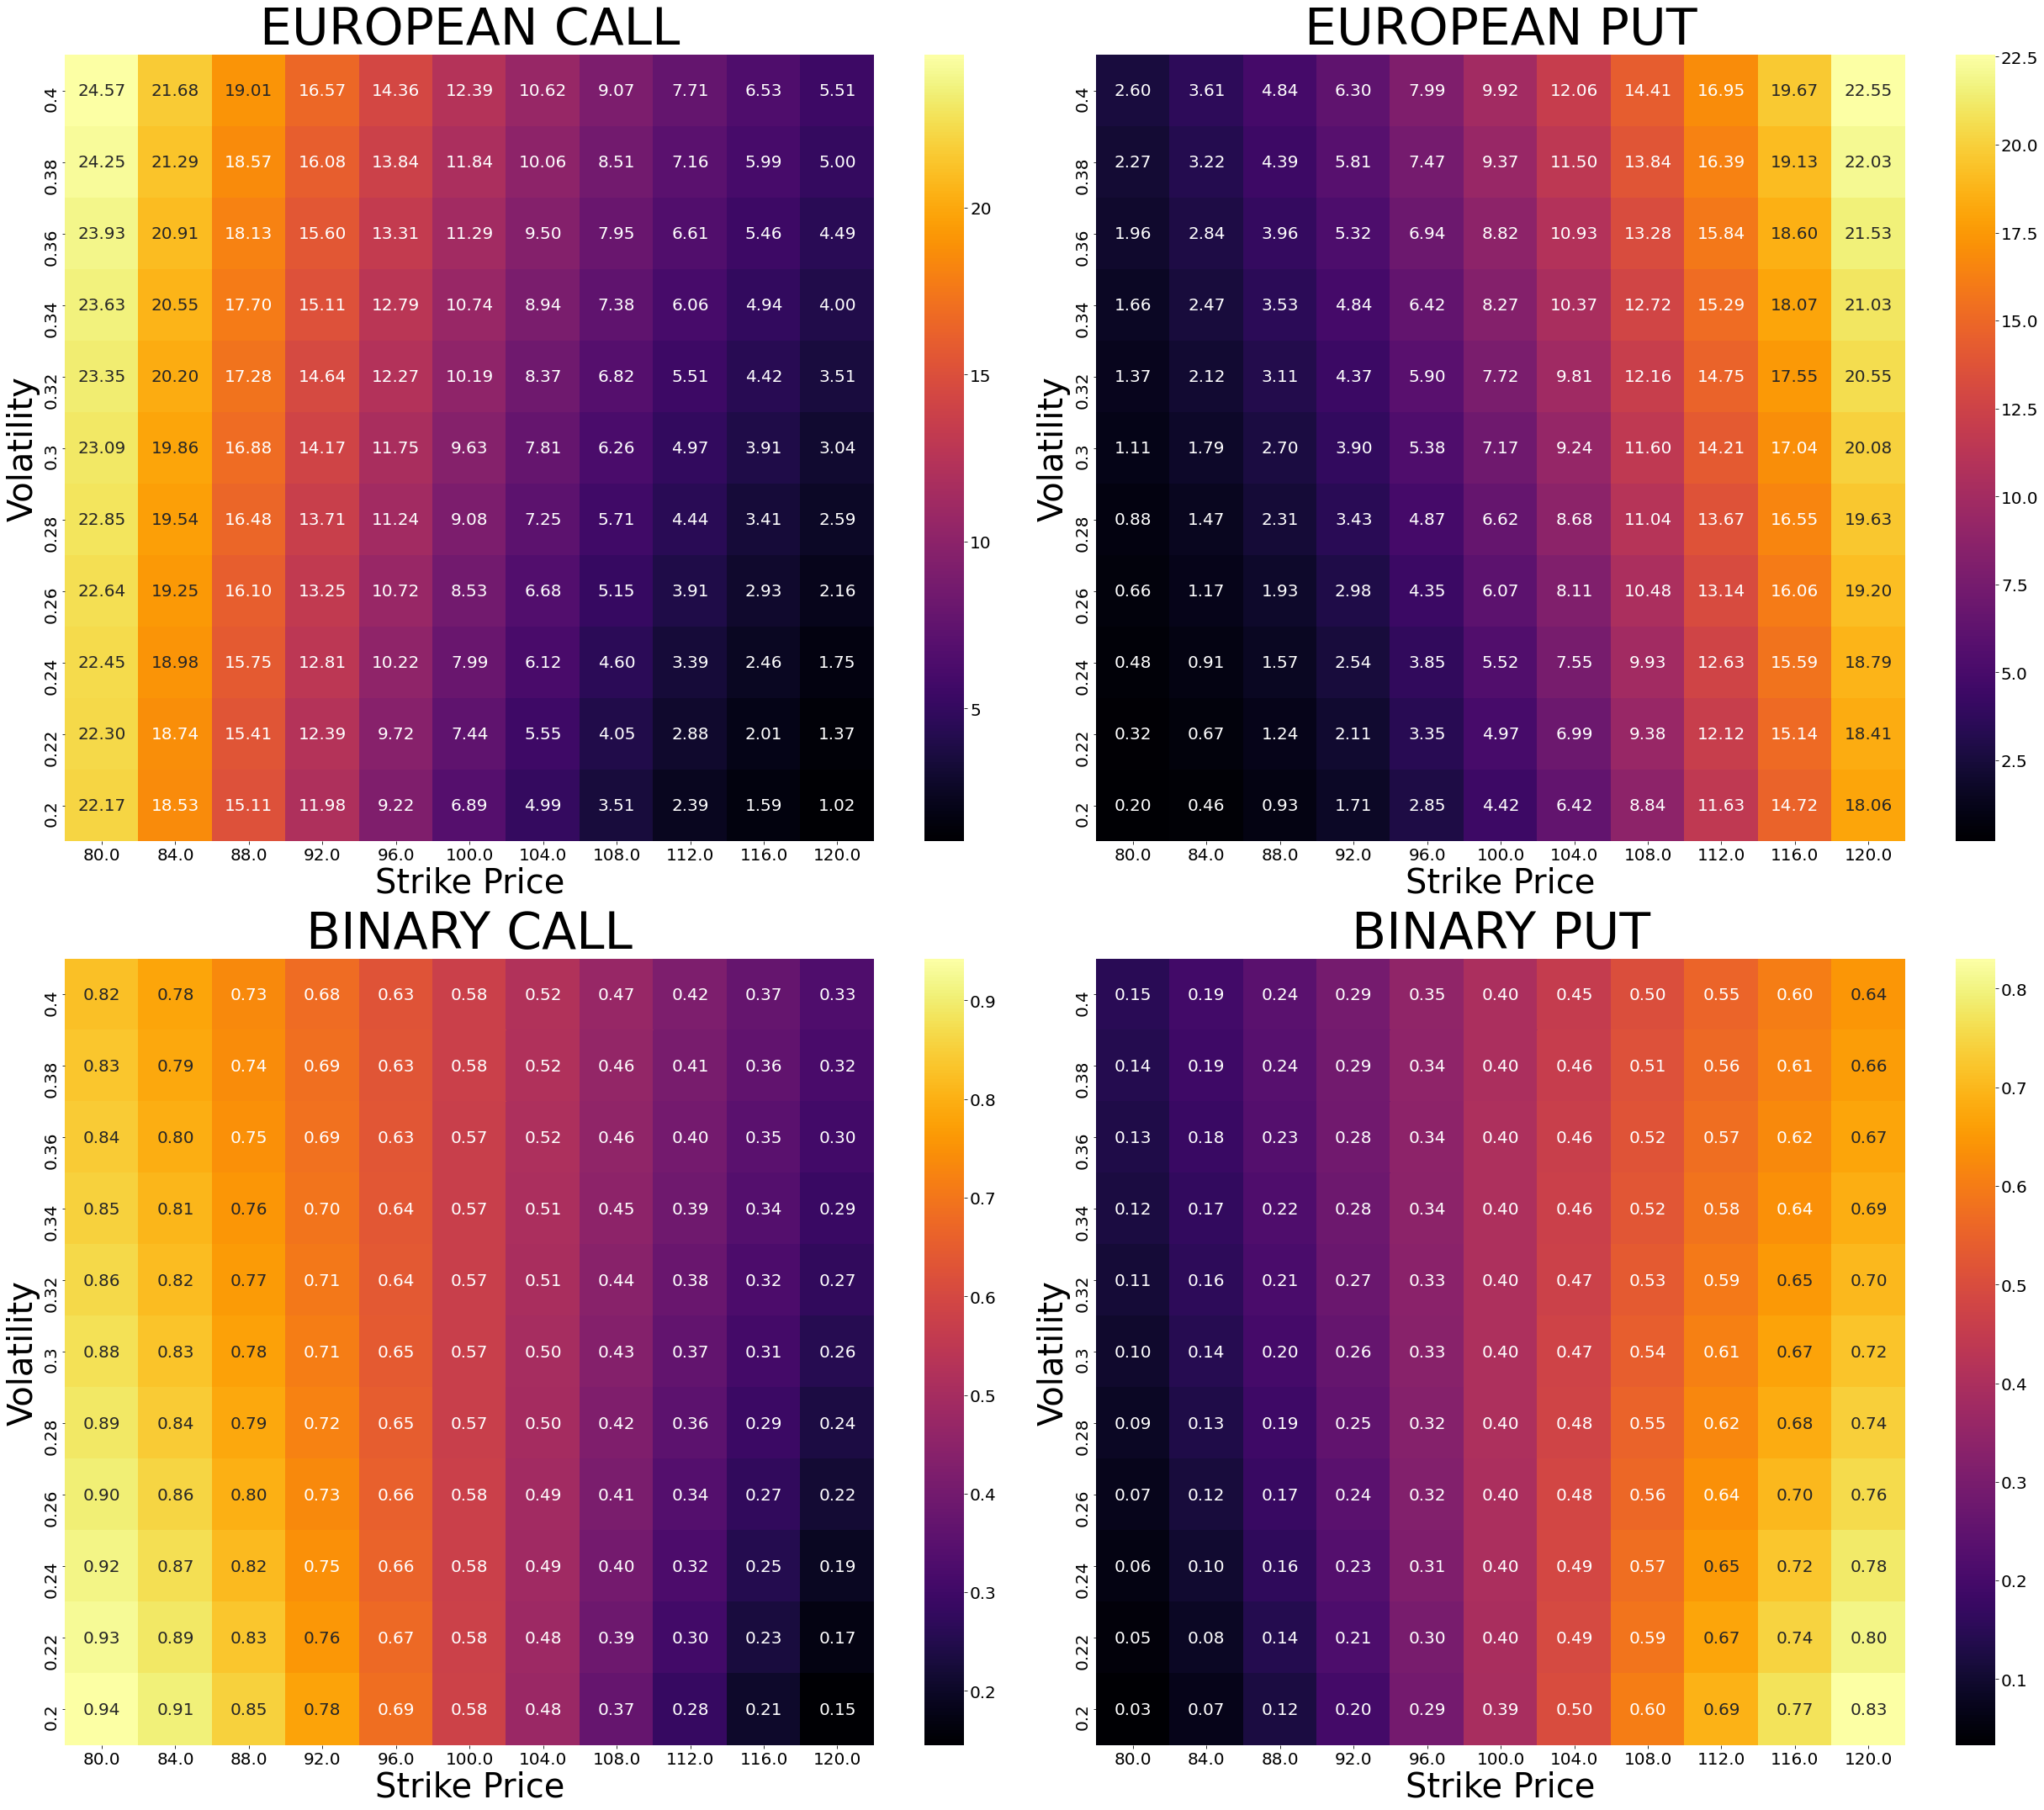

In [8]:
# Test parameters to test our function
S = 100
K = 100
r = 0.05
q = 0
sigma = 0.3
T = 1
t = 0.5
Heatmap(S,K,r,q,sigma,T,t)

In [9]:
# Check to see if values are correct
print('The value of the European Call option at K=100 and sigma=0.3 is:', '{:.2f}'.format(round(Value_EC(S,K,r,q,sigma,T,t),2)))
print('The value of the European Call option at K=80 and sigma=0.4 is:', '{:.2f}'.format(round(Value_EC(S,80,r,q,0.4,T,t),2)))

print('\nThe value of the European Put option at K=100 and sigma=0.3 is:', '{:.2f}'.format(round(Value_EP(S,K,r,q,sigma,T,t),2)))
print('The value of the European Put option at K=120 and sigma=0.2 is:', '{:.2f}'.format(round(Value_EP(S,120,r,q,0.2,T,t),2)))

print('\nThe value of the Binary Call option at K=100 and sigma=0.3 is:', '{:.2f}'.format(round(Value_BC(S,K,r,q,sigma,T,t),2)))
print('The value of the Binary Call option at K=80 and sigma=0.2 is:', '{:.2f}'.format(round(Value_BC(S,80,r,q,0.2,T,t),2)))

print('\nThe value of the Binary Put option at K=100 and sigma=0.3 is:', '{:.2f}'.format(round(Value_BP(S,K,r,q,sigma,T,t),2)))
print('The value of the Binary Put option at K=120 and sigma=0.4 is:', '{:.2f}'.format(round(Value_BP(S,120,r,q,0.4,T,t),2)))

The value of the European Call option at K=100 and sigma=0.3 is: 9.63
The value of the European Call option at K=80 and sigma=0.4 is: 24.57

The value of the European Put option at K=100 and sigma=0.3 is: 7.17
The value of the European Put option at K=120 and sigma=0.2 is: 18.06

The value of the Binary Call option at K=100 and sigma=0.3 is: 0.57
The value of the Binary Call option at K=80 and sigma=0.2 is: 0.94

The value of the Binary Put option at K=100 and sigma=0.3 is: 0.40
The value of the Binary Put option at K=120 and sigma=0.4 is: 0.64
